[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SushrutGaikwad/svm-gmu/blob/main/examples/banana_crescent.ipynb)

# SVM-GMU: Training and Visualization Example

This notebook walks through a complete example of using the SVM-GMU classifier on a 2-D dataset with complex (banana- and crescent-shaped) Gaussian mixture uncertainties. It covers:

1. **Defining the dataset:** Observed points, labels, and per-sample GMM uncertainty descriptions.
2. **Visualizing the uncertainty:** Plotting the GMM density contours before any training.
3. **Training SVM-GMU:** Fitting the uncertainty-aware classifier.
4. **Training a standard SVM:** Fitting without uncertainty for comparison.
5. **Plotting decision boundaries:** The SVM-GMU boundary alone, and a side-by-side comparison with the standard SVM.

In [1]:
# Installing svm-gmu
!pip install git+https://github.com/SushrutGaikwad/svm-gmu.git

  Cloning https://github.com/SushrutGaikwad/svm-gmu.git to /tmp/pip-req-build-r3ye87j7
  Running command git clone --filter=blob:none --quiet https://github.com/SushrutGaikwad/svm-gmu.git /tmp/pip-req-build-r3ye87j7
  Resolved https://github.com/SushrutGaikwad/svm-gmu.git to commit e9c0c03299c0ef0876b0703c58f5202f60d00533
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for svm-gmu: filename=svm_gmu-0.1.0-py3-none-any.whl size=19671 sha256=fe9b05a01bb5067d0da82dc3facd3f6d7d1c8247934f0c612dbcb4743610a935
  Stored in directory: /tmp/pip-ephem-wheel-cache-z97v22xp/wheels/6b/83/4f/dd51d59fbe841272c826fb9c079af9acdb876b2ecbf62150f6
Successfully built svm-gmu


In [2]:
# Imports

import numpy as np
from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_uncertainty, plot_boundary, plot_boundary_comparison

## 1. Define the dataset

We have $n = 6$ training samples in $d = 2$ dimensions. Three belong to class $+1$ and three to class $-1$. Each sample's uncertainty is modeled as a Gaussian mixture with between 5 and 7 components, giving rise to banana and crescent shapes in the density contours.

### Observed feature vectors and class labels

In [3]:
X = np.array([
    [-2.4,  2.4],   # +1
    [-1.5,  4.1],   # +1
    [-2.5,  4.6],   # +1
    [ 3.0, -2.0],   # -1
    [ 2.4, -3.5],   # -1
    [ 3.5, -5.0],   # -1
])
y = np.array([+1, +1, +1, -1, -1, -1])

### Per-sample uncertainty descriptions

Each sample gets a GMM uncertainty dict with keys `"weights"`, `"means"`, and `"covariances"`. The component means are placed along curved arcs to create banana and crescent shapes, and each component's covariance is elongated along the local tangent of the curve.

In [4]:
sample_1 = {
    "weights": np.array([0.12, 0.22, 0.32, 0.22, 0.12]),
    "means": np.array([
        [-3.8,  1.6],
        [-3.5,  2.3],
        [-3.0,  2.6],
        [-2.5,  2.3],
        [-2.2,  1.6],
    ]),
    "covariances": np.array([
        [[ 0.010, -0.012],
         [-0.012,  0.050]],
        [[ 0.015, -0.008],
         [-0.008,  0.040]],
        [[ 0.050,  0.000],
         [ 0.000,  0.010]],
        [[ 0.015,  0.008],
         [ 0.008,  0.040]],
        [[ 0.010,  0.012],
         [ 0.012,  0.050]],
    ]),
}

sample_2 = {
    "weights": np.array([0.08, 0.12, 0.16, 0.28, 0.16, 0.12, 0.08]),
    "means": np.array([
        [-1.9,  3.0],
        [-1.6,  3.7],
        [-1.2,  4.1],
        [-0.7,  4.3],
        [-0.2,  4.1],
        [ 0.2,  3.7],
        [ 0.5,  3.0],
    ]),
    "covariances": np.array([
        [[ 0.008,  0.006],
         [ 0.006,  0.030]],
        [[ 0.010,  0.005],
         [ 0.005,  0.025]],
        [[ 0.025,  0.003],
         [ 0.003,  0.008]],
        [[ 0.035,  0.000],
         [ 0.000,  0.006]],
        [[ 0.025, -0.003],
         [-0.003,  0.008]],
        [[ 0.010, -0.005],
         [-0.005,  0.025]],
        [[ 0.008, -0.006],
         [-0.006,  0.030]],
    ]),
}

sample_3 = {
    "weights": np.array([0.10, 0.25, 0.30, 0.25, 0.10]),
    "means": np.array([
        [-2.0,  4.3],
        [-2.6,  4.8],
        [-3.1,  5.1],
        [-3.4,  5.5],
        [-3.3,  6.0],
    ]),
    "covariances": np.array([
        [[ 0.040, -0.010],
         [-0.010,  0.012]],
        [[ 0.030, -0.015],
         [-0.015,  0.015]],
        [[ 0.015, -0.010],
         [-0.010,  0.030]],
        [[ 0.008,  0.005],
         [ 0.005,  0.035]],
        [[ 0.012,  0.012],
         [ 0.012,  0.040]],
    ]),
}

sample_4 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [ 2.2, -1.5],
        [ 2.7, -2.2],
        [ 3.3, -2.5],
        [ 3.9, -2.2],
        [ 4.2, -1.5],
        [ 4.1, -0.8],
    ]),
    "covariances": np.array([
        [[ 0.008,  0.008],
         [ 0.008,  0.030]],
        [[ 0.012,  0.006],
         [ 0.006,  0.025]],
        [[ 0.030,  0.000],
         [ 0.000,  0.007]],
        [[ 0.012, -0.006],
         [-0.006,  0.025]],
        [[ 0.008, -0.008],
         [-0.008,  0.030]],
        [[ 0.025, -0.010],
         [-0.010,  0.012]],
    ]),
}

sample_5 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [ 0.8, -3.0],
        [ 1.1, -3.6],
        [ 1.6, -4.0],
        [ 2.1, -3.8],
        [ 2.4, -3.3],
    ]),
    "covariances": np.array([
        [[ 0.010,  0.010],
         [ 0.010,  0.045]],
        [[ 0.015,  0.008],
         [ 0.008,  0.035]],
        [[ 0.045,  0.000],
         [ 0.000,  0.010]],
        [[ 0.015, -0.008],
         [-0.008,  0.035]],
        [[ 0.010, -0.010],
         [-0.010,  0.045]],
    ]),
}

sample_6 = {
    "weights": np.array([0.06, 0.12, 0.18, 0.28, 0.18, 0.12, 0.06]),
    "means": np.array([
        [ 1.7, -5.2],
        [ 2.1, -5.8],
        [ 2.6, -6.0],
        [ 3.1, -5.8],
        [ 3.5, -5.3],
        [ 3.6, -4.7],
        [ 3.3, -4.2],
    ]),
    "covariances": np.array([
        [[ 0.008,  0.006],
         [ 0.006,  0.028]],
        [[ 0.020,  0.008],
         [ 0.008,  0.010]],
        [[ 0.030,  0.000],
         [ 0.000,  0.006]],
        [[ 0.020, -0.008],
         [-0.008,  0.010]],
        [[ 0.008, -0.008],
         [-0.008,  0.028]],
        [[ 0.006, -0.006],
         [-0.006,  0.030]],
        [[ 0.015,  0.010],
         [ 0.010,  0.015]],
    ]),
}

sample_uncertainty = [sample_1, sample_2, sample_3,
                      sample_4, sample_5, sample_6]

## 2. Visualize the uncertainty (data only)

Before training any model, we can inspect the dataset using `plot_uncertainty`. Each sample's GMM density is shown as nested filled contours at the $1\sigma$, $2\sigma$, $3\sigma$, and $4\sigma$ levels.

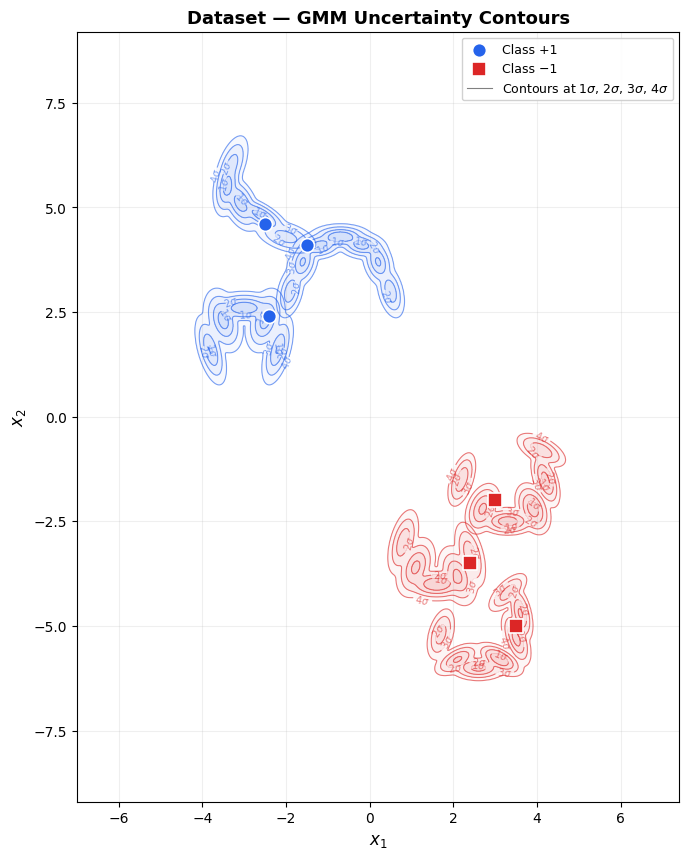

In [5]:
fig, ax = plot_uncertainty(
    X, y, sample_uncertainty,
    sigmas=(1, 2, 3, 4),
    figsize=(10, 10),
    title="Dataset — GMM Uncertainty Contours",
)

The blue contours (class $+1$) and red contours (class $-1$) show where the classifier believes the true location of each sample might lie. The banana and crescent shapes are clearly visible.

## 3. Train SVM-GMU (uncertainty-aware)

We now train the SVM-GMU model, passing the full GMM uncertainty for each sample. We use full-batch SGD (`batch_size=6`, since $n = 6$) for stable convergence.

In [6]:
model_gmu = SvmGmu(
    lam=0.01,
    max_iter=50,
    batch_size=6,
    random_state=42,
    verbose=True,
    log_interval=2,
)
model_gmu.fit(X, y, sample_uncertainty=sample_uncertainty)

  iter      2 / 50  |  objective = 0.125000
  iter      4 / 50  |  objective = 0.031250
  iter      6 / 50  |  objective = 0.013889
  iter      8 / 50  |  objective = 0.007812
  iter     10 / 50  |  objective = 0.005000
  iter     12 / 50  |  objective = 0.003472
  iter     14 / 50  |  objective = 0.002551
  iter     16 / 50  |  objective = 0.001953
  iter     18 / 50  |  objective = 0.001546
  iter     20 / 50  |  objective = 0.001296
  iter     22 / 50  |  objective = 0.001178
  iter     24 / 50  |  objective = 0.001150
  iter     26 / 50  |  objective = 0.001149
  iter     28 / 50  |  objective = 0.001148
  iter     30 / 50  |  objective = 0.001148
  iter     32 / 50  |  objective = 0.001148
  iter     34 / 50  |  objective = 0.001148
  iter     36 / 50  |  objective = 0.001148
  iter     38 / 50  |  objective = 0.001148
  iter     40 / 50  |  objective = 0.001147
  iter     42 / 50  |  objective = 0.001147
  iter     44 / 50  |  objective = 0.001147
  iter     46 / 50  |  objective

SvmGmu(batch_size=6, log_interval=2, max_iter=50, random_state=42, verbose=True)

In [7]:
print(f"\nSVM-GMU:  w = {model_gmu.coef_},  b = {model_gmu.intercept_:.4f}")


SVM-GMU:  w = [-0.23296699  0.40175399],  b = 0.0293


## 4. Train a standard SVM (no uncertainty)

For comparison, we train the same model without any uncertainty information. When `sample_uncertainty` is omitted, each sample is treated as a point mass and the model reduces to a standard linear SVM.

In [8]:
model_svm = SvmGmu(
    lam=0.01,
    max_iter=5000,
    batch_size=6,
    random_state=42,
    verbose=True,
    log_interval=1000,
)
model_svm.fit(X, y)

  iter   1000 / 5000  |  objective = 0.000445
  iter   2000 / 5000  |  objective = 0.000430
  iter   3000 / 5000  |  objective = 0.000429
  iter   4000 / 5000  |  objective = 0.000470
  iter   5000 / 5000  |  objective = 0.000426


SvmGmu(batch_size=6, log_interval=1000, max_iter=5000, random_state=42,
       verbose=True)

In [9]:
print(f"\nStd SVM:   w = {model_svm.coef_},  b = {model_svm.intercept_:.4f}")


Std SVM:   w = [-0.22515603  0.18563205],  b = 0.0298


## 5. Plot the SVM-GMU decision boundary

`plot_boundary` overlays the learned decision boundary (solid black line at $\mathbf{w}^\intercal \mathbf{x} + b = 0$) and the margin lines (dashed at $\pm 1$) on top of the uncertainty contours.

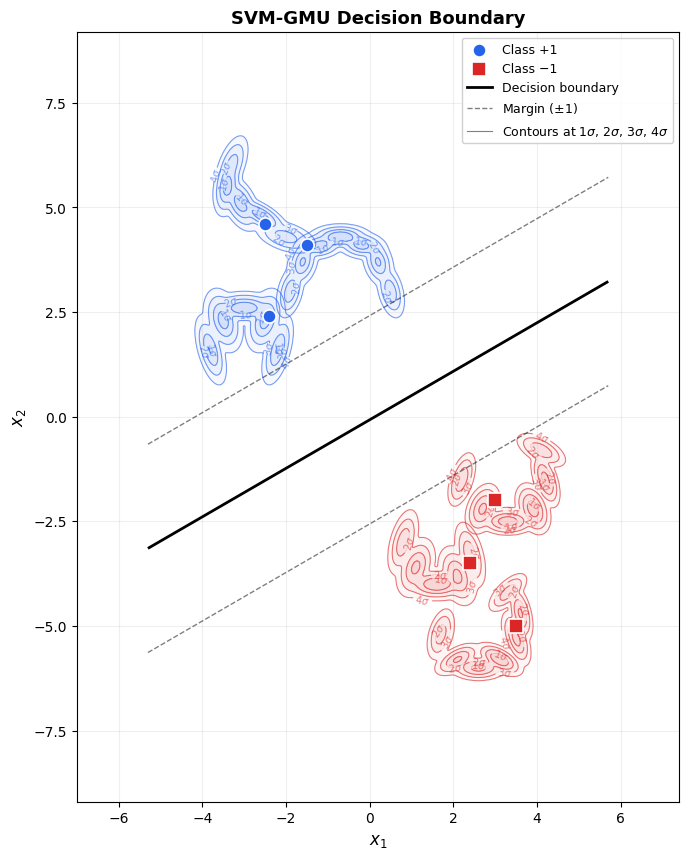

In [10]:
fig, ax = plot_boundary(
    X, y, sample_uncertainty, model_gmu,
    sigmas=(1, 2, 3, 4),
    figsize=(10, 10),
    title="SVM-GMU Decision Boundary",
)

## 6. Compare SVM-GMU vs. standard SVM

`plot_boundary_comparison` places both models side by side on the same dataset. This makes it easy to see how the uncertainty-aware training shifts the decision boundary compared to the standard SVM.

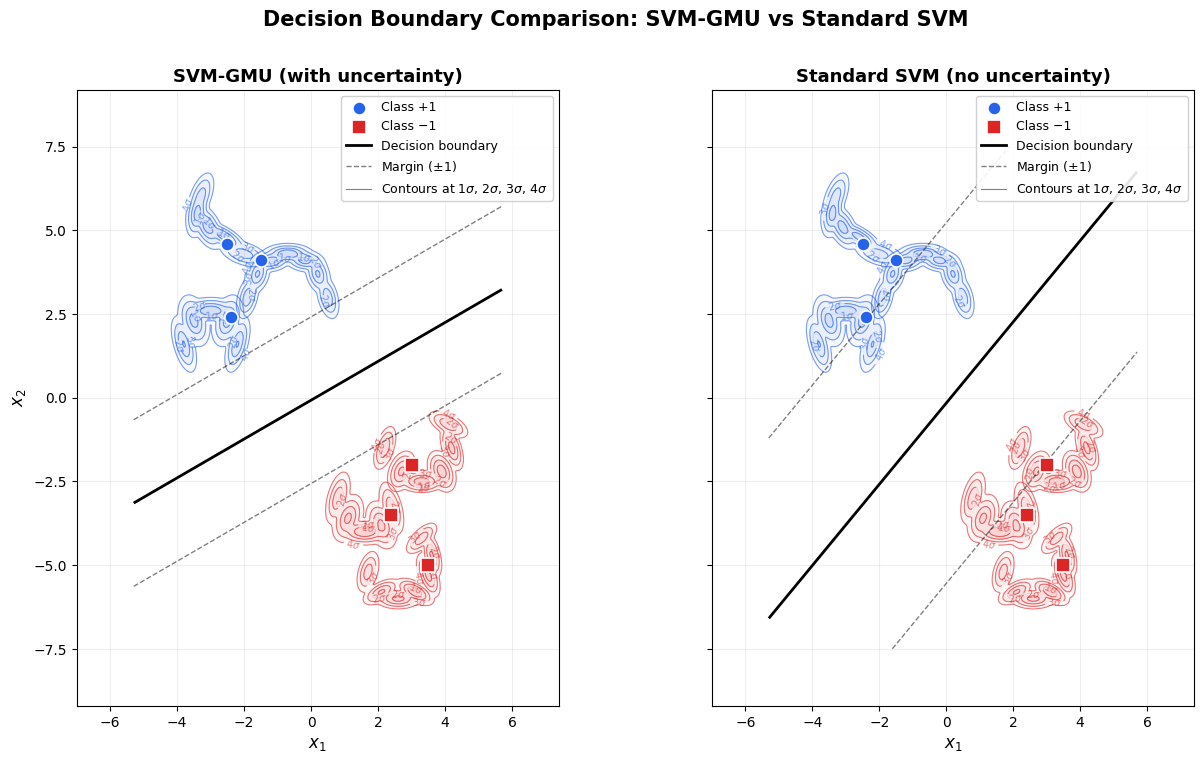

In [11]:
fig, (ax_left, ax_right) = plot_boundary_comparison(
    X, y, sample_uncertainty,
    model_gmu, model_svm,
    sigmas=(1, 2, 3, 4),
)

## 7. Check predictions

Both models predict using the standard hyperplane rule $\hat{y} = \mathrm{sign}(\mathbf{w}^\intercal \mathbf{x} + b)$. No uncertainty is used at prediction time.

In [12]:
print("SVM-GMU predictions:", model_gmu.predict(X))
print("Std SVM  predictions:", model_svm.predict(X))

SVM-GMU predictions: [ 1.  1.  1. -1. -1. -1.]
Std SVM  predictions: [ 1.  1.  1. -1. -1. -1.]


In [13]:
print("SVM-GMU decision scores:", np.round(model_gmu.decision_function(X), 4))
print("Std SVM  decision scores:", np.round(model_svm.decision_function(X), 4))

SVM-GMU decision scores: [ 1.5527  2.026   2.4598 -1.4731 -1.9359 -2.7948]
Std SVM  decision scores: [ 1.0157  1.1286  1.4466 -1.0169 -1.1603 -1.6864]
